[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/RO/capitol9_notebook_curs.ipynb)

# Modelarea piețelor financiare — Capitolul 9: Volatilitate realizată

*Notebook de curs. Daniel Traian Pele, Academia de Studii Economice din București.*

Acest notebook reproduce toate graficele și tabelele din Cursul 9 pe date de 5 minute pentru SPY și Bitcoin.

In [1]:
# Pe Colab, instalați întâi arch: !pip install arch
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Stil și funcții ajutătoare

In [2]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand (gri doar pentru linii de referinta si benzi)
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Teal     = '#17A2B8'
Gray     = '#7F7F7F'
LightGray = '#DADADA'
MODEL_COL = {'logHAR': IDAred, 'HAR': Orange, 'GARCH-t': MainBlue, 'EWMA': Purple, 'RW': Forest}

HERE = '.'
SEED = 42
OOS_SPY = '2022-01-03'
OOS_BTC = '2025-03-01'
B_BOOT = 2000
C_START = '2025-03-01'


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=0.0):
    """O singura legenda pentru o figura cu mai multe panouri, sub figura."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            h, l = ax.get_legend_handles_labels()
            for hh, ll in zip(h, l):
                if ll not in labels:
                    handles.append(hh)
                    labels.append(ll)
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def jsonable(x):
    if isinstance(x, dict):
        return {str(k): jsonable(v) for k, v in x.items()}
    if isinstance(x, (list, tuple, np.ndarray)):
        return [jsonable(v) for v in x]
    if isinstance(x, (np.floating, np.integer)):
        return x.item()
    if isinstance(x, (np.bool_,)):
        return bool(x)
    if isinstance(x, pd.Timestamp):
        return str(x.date())
    return x


def ann(v, ppy):
    """Volatilitatea anualizata (%) dintr-o varianta zilnica (%^2)."""
    return np.sqrt(ppy * v)


import tempfile
HERE = tempfile.gettempdir()   # tabelele intermediare sunt scrise intr-un folder temporar


def save_fig(name):
    """Afiseaza figura."""
    plt.show()
    plt.close()

## Măsuri realizate, HAR și evaluarea prognozelor

- `rv`, `bv`, `tq`, `rq`, `rv_ci`, `jump_test`: varianța realizată, variația bipower, cvarticități, interval de încredere, testul de salturi.
- `sparse_rv`, `subsampled_rv`, `signature`, `tsrv`, `realized_kernel`, `noise_var`: eșantionare și zgomot de microstructură.
- `har_design`, `ols_nw`, `har_fit`, `har_expanding`, `har_weights`: HAR-RV cu erori Newey–West și prognoze în afara eșantionului.
- `garch_forecasts`, `ewma_forecasts`, `qlike`, `mse`, `dm_test`, `mz_test`, `block_bootstrap`, `roughness`.

In [3]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.special import gamma as G

MU1 = np.sqrt(2 / np.pi)                              # E|Z|, Z ~ N(0,1)
MU43 = 2 ** (2 / 3) * G(7 / 6) / G(1 / 2)             # E|Z|^{4/3}


# =============================================================================
# ESTIMATORI REALIZATI (o valoare pe zi)
# =============================================================================
def rv(R):
    """Varianta realizata: suma patratelor randamentelor intraday."""
    return (R ** 2).sum(axis=1, min_count=1)


def nret(R):
    """Numarul de randamente intraday al fiecarei zile."""
    return R.notna().sum(axis=1)


def bv(R):
    """Variatia bipower (Barndorff-Nielsen si Shephard): robusta la salturi."""
    a = R.abs().values
    M = nret(R).values
    s = np.nansum(a[:, 1:] * a[:, :-1], axis=1)
    return pd.Series(MU1 ** -2 * M / (M - 1) * s, index=R.index)


def tq(R):
    """Tripower quarticity: estimeaza cvarticitatea integrata, robusta la salturi."""
    a = R.abs().values ** (4 / 3)
    M = nret(R).values
    s = np.nansum(a[:, 2:] * a[:, 1:-1] * a[:, :-2], axis=1)
    return pd.Series(M * MU43 ** -3 * M / (M - 2) * s, index=R.index)


def rq(R):
    """Cvarticitatea realizata (M/3) * suma r^4."""
    return nret(R) / 3 * (R ** 4).sum(axis=1)


def rv_ci(R, level=0.95):
    """Interval de incredere asimptotic pentru varianta integrata, construit pe scara log."""
    v = rv(R)
    se_log = np.sqrt(2 / 3 * (R ** 4).sum(axis=1)) / v
    z = stats.norm.ppf(0.5 + level / 2)
    return v * np.exp(-z * se_log), v * np.exp(z * se_log)


def jump_test(R, alpha=0.001):
    """Testul de salturi cu raportul (RV - BV)/RV (Huang si Tauchen); salt semnificativ daca z > z_{1-alpha}."""
    v, b, t = rv(R), bv(R), tq(R)
    M = nret(R)
    theta = MU1 ** -4 + 2 * MU1 ** -2 - 5
    z = ((v - b) / v) / np.sqrt(theta / M * np.maximum(1, t / b ** 2))
    jump = z > stats.norm.ppf(1 - alpha)
    J = np.where(jump, np.maximum(v - b, 0), 0.0)
    return pd.DataFrame({'rv': v, 'bv': b, 'tq': t, 'z': z, 'jump': jump, 'J': J, 'C': v - J})


# =============================================================================
# ZGOMOT DE MICROSTRUCTURA
# =============================================================================
def sparse_points(P, k, offset=0):
    """Preturile la fiecare al k-lea punct al grilei, pornind de la offset; deschiderea si inchiderea se pastreaza."""
    out = {}
    last = P.notna().values.cumsum(axis=1).argmax(axis=1)
    cols = np.arange(P.shape[1])
    X = P.values
    for i, day in enumerate(P.index):
        idx = cols[(cols >= offset) & ((cols - offset) % k == 0) & (cols <= last[i])]
        idx = np.unique(np.r_[0, idx, last[i]])
        out[day] = np.log(X[i, idx])
    return out


def sparse_rv(P, k, offset=0):
    """Varianta realizata din randamente de k x 5 minute (o singura grila)."""
    pts = sparse_points(P, k, offset)
    return pd.Series({d: np.sum((100 * np.diff(x)) ** 2) for d, x in pts.items()})


def subsampled_rv(P, k):
    """Media variantelor realizate pe cele k grile decalate (esantionare rara fara pierdere de date)."""
    return pd.concat([sparse_rv(P, k, o) for o in range(k)], axis=1).mean(axis=1)


def signature(P, ks, scale):
    """Graficul semnaturii: volatilitatea anualizata medie (%) in functie de intervalul de esantionare."""
    return pd.DataFrame({
        'sparse': [np.sqrt(scale * sparse_rv(P, k).mean()) for k in ks],
        'subsampled': [np.sqrt(scale * subsampled_rv(P, k).mean()) for k in ks]}, index=list(ks))


def tsrv(P, K=6):
    """Two-scale realised variance (Zhang, Mykland si Ait-Sahalia): media pe K grile minus corectia de zgomot."""
    R = 100 * np.log(P).diff(axis=1).iloc[:, 1:]
    n = nret(R)
    nbar = (n - K + 1) / K
    return subsampled_rv(P, K) - nbar / n * rv(R)


def noise_var(R):
    """Varianta zgomotului: omega^2 = -cov(r_i, r_{i-1}) si limita superioara RV/(2n), medii pe zile."""
    X = R.values
    cov1 = np.nanmean(X[:, 1:] * X[:, :-1])
    return {'omega2_cov': max(-cov1, 0.0), 'omega2_rv': float((rv(R) / (2 * nret(R))).mean()),
            'rho1': float(pd.Series(X[:, 1:].ravel()).corr(pd.Series(X[:, :-1].ravel())))}


def parzen(x):
    x = np.abs(x)
    return np.where(x <= 0.5, 1 - 6 * x ** 2 + 6 * x ** 3, np.where(x <= 1, 2 * (1 - x) ** 3, 0.0))


def realized_kernel(R, P, c=3.5134):
    """Nucleu realizat Parzen (Barndorff-Nielsen, Hansen, Lunde si Shephard); latimea H dupa regula lor."""
    out, Hs = {}, {}
    iv20 = sparse_rv(P, 4)                                  # varianta pe grila de 20 de minute, pentru xi
    for i, day in enumerate(R.index):
        r = R.iloc[i].dropna().values
        n = len(r)
        om2 = np.sum(r ** 2) / (2 * n)
        xi2 = om2 / max(iv20[day], 1e-12)
        H = max(1, int(np.ceil(c * xi2 ** 0.4 * n ** 0.6)))
        g = [np.sum(r[h:] * r[:n - h]) for h in range(H + 1)]
        out[day] = g[0] + 2 * sum(parzen(h / (H + 1)) * g[h] for h in range(1, H + 1))
        Hs[day] = H
    return pd.Series(out), pd.Series(Hs)


# =============================================================================
# HAR-RV
# =============================================================================
def har_design(v, calendar=False):
    """Regresori HAR: componenta zilnica, saptamanala, lunara (5 si 22 de zile de tranzactionare;
    pentru cripto, pe calendar: 7 si 30 de zile, cu cel putin 5, respectiv 20 de observatii)."""
    if calendar:
        full = v.asfreq('D')
        d = full.shift(1)
        w = full.rolling(7, min_periods=5).mean().shift(1)
        m = full.rolling(30, min_periods=20).mean().shift(1)
        X = pd.DataFrame({'d': d, 'w': w, 'm': m}).reindex(v.index)
    else:
        X = pd.DataFrame({'d': v.shift(1), 'w': v.rolling(5).mean().shift(1), 'm': v.rolling(22).mean().shift(1)})
    return X


def nw_lags(T):
    return int(np.floor(4 * (T / 100) ** (2 / 9)))


def ols_nw(y, X, lags=None):
    """MCO cu termen liber si erori standard Newey-West (HAC)."""
    Xc = np.column_stack([np.ones(len(X)), np.asarray(X, float)])
    y = np.asarray(y, float)
    T, k = Xc.shape
    XtX_inv = np.linalg.inv(Xc.T @ Xc)
    b = XtX_inv @ Xc.T @ y
    e = y - Xc @ b
    L = nw_lags(T) if lags is None else lags
    u = Xc * e[:, None]
    S = u.T @ u
    for l in range(1, L + 1):
        w = 1 - l / (L + 1)
        g = u[l:].T @ u[:-l]
        S += w * (g + g.T)
    V = XtX_inv @ S @ XtX_inv
    r2 = 1 - e @ e / np.sum((y - y.mean()) ** 2)
    return {'b': b, 'se': np.sqrt(np.diag(V)), 'V': V, 'r2': r2, 'resid': e, 'T': T, 'lags': L}


def har_fit(v, calendar=False, log=False, jumps=None):
    """HAR-RV pe esantionul complet; log=True: HAR pe log RV; jumps: componenta de salt ca regresor suplimentar."""
    X = har_design(np.log(v) if log else v, calendar)
    if jumps is not None:
        X['J'] = jumps.shift(1).reindex(X.index) if not calendar else jumps.asfreq('D').shift(1).reindex(X.index)
    y = np.log(v) if log else v
    ok = X.notna().all(axis=1)
    return ols_nw(y[ok], X[ok]), X, ok


def har_expanding(v, start, calendar=False, log=False, min_obs=100):
    """Prognoze HAR pentru ziua t, estimate zilnic pe toate observatiile anterioare lui t (fereastra extinsa)."""
    y = np.log(v) if log else v
    X = har_design(y, calendar)
    ok = X.notna().all(axis=1)
    Xv, yv = X.values, y.values
    Xc = np.column_stack([np.ones(len(X)), Xv])
    out = {}
    for t in np.where((v.index >= pd.Timestamp(start)) & ok.values)[0]:
        tr = np.where(ok.values[:t])[0]
        if len(tr) < min_obs:
            continue
        b, *_ = np.linalg.lstsq(Xc[tr], yv[tr], rcond=None)
        f = Xc[t] @ b
        if log:
            s2 = np.var(yv[tr] - Xc[tr] @ b)
            f = np.exp(f + s2 / 2)
        out[v.index[t]] = f
    return pd.Series(out)


def har_weights(b, n=30):
    """Ponderile implicite ale HAR pe fiecare intarziere 1..n (HAR = AR(22) restrictionat)."""
    w = np.zeros(n)
    w[0] += b[1]
    w[:5] += b[2] / 5
    w[:22] += b[3] / 22
    return w


# =============================================================================
# REPERE: GARCH SI EWMA PE RANDAMENTE ZILNICE
# =============================================================================
def garch_forecasts(r, dates, refit=21, dist='t'):
    """Varianta prognozata pentru fiecare zi din dates cu GARCH(1,1), reestimat la fiecare `refit` zile
    pe toate datele anterioare; intre reestimari parametrii raman fixi, iar varianta se actualizeaza zilnic."""
    from arch import arch_model
    dates = pd.DatetimeIndex(dates)
    pos = r.index.get_indexer(dates)
    out = pd.Series(np.nan, index=dates)
    for i0 in range(0, len(dates), refit):
        blk = dates[i0:i0 + refit]
        p0 = pos[i0]
        fit = arch_model(r.iloc[:p0], mean='Constant', vol='GARCH', p=1, q=1, dist=dist).fit(disp='off')
        fixed = arch_model(r.iloc[:pos[min(i0 + refit, len(dates)) - 1] + 1], mean='Constant', vol='GARCH', p=1, q=1,
                           dist=dist).fix(fit.params)
        out[blk] = (fixed.conditional_volatility ** 2).reindex(blk).values
    return out


def ewma_forecasts(r, lam=0.94, burn=250):
    """RiskMetrics: sigma^2_t = lambda sigma^2_{t-1} + (1 - lambda) r^2_{t-1}."""
    x = r.values
    s = np.empty(len(x))
    s[0] = np.var(x[:burn])
    for t in range(1, len(x)):
        s[t] = lam * s[t - 1] + (1 - lam) * x[t - 1] ** 2
    return pd.Series(s, index=r.index)


# =============================================================================
# EVALUAREA PROGNOZELOR
# =============================================================================
def qlike(v, f):
    """QLIKE: v/f - log(v/f) - 1 (robusta la zgomotul proxy-ului, Patton 2011)."""
    return v / f - np.log(v / f) - 1


def mse(v, f):
    return (v - f) ** 2


def dm_test(l1, l2):
    """Diebold-Mariano: d = l1 - l2; t = media(d)/se_NW; d < 0 => modelul 1 are pierdere mai mica."""
    d = (l1 - l2).dropna().values
    res = ols_nw(d, np.empty((len(d), 0)))
    t = res['b'][0] / res['se'][0]
    return {'mean_diff': float(d.mean()), 't': float(t), 'p': float(2 * stats.norm.sf(abs(t))), 'T': len(d)}


def mz_test(v, f):
    """Regresia Mincer-Zarnowitz v = a + b f + e; test Wald comun (a, b) = (0, 1) cu covarianta NW."""
    res = ols_nw(v.values, f.values[:, None])
    dlt = res['b'] - np.array([0.0, 1.0])
    W = float(dlt @ np.linalg.inv(res['V']) @ dlt)
    return {'a': res['b'][0], 'b': res['b'][1], 'se_a': res['se'][0], 'se_b': res['se'][1], 'r2': res['r2'],
            'wald': W, 'p': float(stats.chi2.sf(W, 2))}


def block_bootstrap(x, stat, block=20, B=2000, seed=42):
    """Bootstrap pe blocuri mobile (Kunsch): distributia statisticii `stat` pe serii reconstruite din blocuri."""
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    n = len(x)
    nb = int(np.ceil(n / block))
    out = np.empty(B)
    for b in range(B):
        starts = rng.integers(0, n - block + 1, nb)
        idx = (starts[:, None] + np.arange(block)[None, :]).ravel()[:n]
        out[b] = stat(x[idx])
    return out


# =============================================================================
# VOLATILITATE ASPRA
# =============================================================================
def roughness(logsig, qs=(0.5, 1.0, 1.5, 2.0, 3.0), lags=range(1, 31)):
    """m(q, D) = media |log sigma_{t+D} - log sigma_t|^q ~ D^{q H}: panta zeta_q = q H pe scara log-log."""
    x = np.asarray(logsig)
    lags = np.array(list(lags))
    M = {q: np.array([np.mean(np.abs(x[l:] - x[:-l]) ** q) for l in lags]) for q in qs}
    zeta = {q: np.polyfit(np.log(lags), np.log(M[q]), 1)[0] for q in qs}
    H = np.polyfit(list(qs), [zeta[q] for q in qs], 1)[0] if len(qs) > 1 else zeta[qs[0]] / qs[0]
    return {'lags': lags, 'm': M, 'zeta': zeta, 'H': float(H)}

## Date

- SPY: bare de 5 minute din sesiunea regulată din SUA (09:30–16:00 ora New York), octombrie 2020 – septembrie 2026.
- Bitcoin: bare de 5 minute, zile UTC de 24 de ore cu cel puțin 95% din bare, septembrie 2024 – septembrie 2026.
- Închideri zilnice SPY (ajustate) și Bitcoin și indicele VIX.
- Randamente în %, varianțe zilnice în %²; varianța zilnică totală SPY = RV intraday + randamentul peste noapte la pătrat.

In [4]:
import os
import numpy as np
import pandas as pd

REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# nume -> (simbol, coloana, eticheta, 7 zile din 7?)
DAILY = {
    'spy': ('SPY.US', 'adjusted_close', 'SPY (S&P 500 ETF)', False),
    'sp500': ('GSPC.INDX', 'close', 'S&P 500', False),
    'btc': ('BTC-USD.CC', 'close', 'Bitcoin', True),
    'vix': ('VIX.INDX', 'close', 'VIX', False),
}


def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_intraday(symbol):
    """Citeste data/market/intraday/<SIMBOL>_5m.csv (ora UTC)."""
    fname = f'intraday/{symbol}_5m.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    d = pd.read_csv(src, index_col='datetime_utc', parse_dates=True).sort_index()
    return d[~d.index.duplicated(keep='last')]


def daily_close(name, start=None, end=END):
    """Pretul zilnic: fara cotatii de weekend (in afara de cripto) si fara zile cu pret neschimbat (indici)."""
    symbol, col, _, all_week = DAILY[name]
    s = read_market(symbol)[col].loc[start:end]
    s = s[s > 0].dropna()
    if not all_week:
        s = s[s.index.dayofweek < 5]
    if name in ('sp500', 'vix'):
        s = s[s.diff() != 0]
    return s.rename(name)


def daily_returns(name, start=None, end=END):
    """Randamente log zilnice, in %, pe calendarul propriu al seriei."""
    return (100 * np.log(daily_close(name, start, end)).diff().dropna()).rename(name)


def spy_intraday(end=END):
    """Preturile SPY din sesiunea regulata: matrice zi x 79 de puncte (deschiderea de 09:30 + 78 de inchideri)."""
    d = read_intraday('SPY.US')
    d.index = d.index.tz_localize('UTC').tz_convert('America/New_York')
    d = d[(d.index.second == 0) & (d.index.minute % 5 == 0)]            # fara bare din afara grilei
    mins = d.index.hour * 60 + d.index.minute
    d = d[(mins >= 9 * 60 + 30) & (mins <= 15 * 60 + 55)]               # 09:30-15:55 (fara bara-ciot de 16:00)
    d = d.loc[:end + ' 23:59']
    slot = ((d.index.hour * 60 + d.index.minute) - (9 * 60 + 30)) // 5  # 0..77
    day = pd.to_datetime(d.index.date)
    close = pd.DataFrame({'day': day, 'slot': slot, 'p': d['close'].values}).pivot(index='day', columns='slot', values='p')
    first = pd.Series(d['open'].values, index=day)[slot == 0]
    first = first[~first.index.duplicated()]
    P = pd.concat([first.rename(-1), close], axis=1).sort_index(axis=1)
    P = P[P[0].notna() & P[-1].notna()]
    P.columns = range(P.shape[1])                                        # 0 = deschiderea, 1..78 = inchiderile barelor
    last = P.notna().values.cumsum(axis=1).argmax(axis=1)                # ultima bara disponibila a zilei
    F = P.ffill(axis=1)                                                  # bare lipsa in interiorul zilei: pretul anterior
    F = F.where(np.arange(P.shape[1])[None, :] <= last[:, None])         # dupa inchiderea zilelor scurte: NaN
    return F


def btc_intraday(end=END, min_share=0.95):
    """Preturile Bitcoin pe zile UTC: matrice zi x 289 de puncte (deschiderea de 00:00 + 288 de inchideri)."""
    d = read_intraday('BTC-USD.CC')
    d = d[d['close'].notna() & (d['close'] > 0)].loc[:end + ' 23:59']
    g = d.resample('5min', label='left', closed='left').agg({'open': 'first', 'close': 'last'})
    have = g['close'].notna()
    day = pd.to_datetime(g.index.date)
    n = have.groupby(day).sum()
    keep = n[n >= min_share * 288].index
    g = g[day.isin(keep)]
    day = pd.to_datetime(g.index.date)
    slot = (g.index.hour * 60 + g.index.minute) // 5
    close = pd.DataFrame({'day': day, 'slot': slot, 'p': g['close'].values}).pivot(index='day', columns='slot', values='p')
    close = close.ffill(axis=1)                                          # goluri scurte: ultimul pret cunoscut
    op = pd.DataFrame({'day': day, 'slot': slot, 'p': g['open'].values}).pivot(index='day', columns='slot', values='p')
    first = op.bfill(axis=1)[0].fillna(close[0])
    close = close.bfill(axis=1)                                          # zi care incepe cu un gol
    P = pd.concat([first.rename(-1), close], axis=1).sort_index(axis=1)
    P.columns = range(P.shape[1])
    return P


def intraday_returns(P):
    """Randamentele log intr-o zi, in %: coloana j = intervalul (j-1, j]; NaN dupa inchiderea zilelor scurte."""
    return 100 * np.log(P).diff(axis=1).iloc[:, 1:]


def spy_overnight(P):
    """Randamentul peste noapte (%): randamentul zilnic ajustat minus randamentul deschidere-inchidere al zilei."""
    oc = 100 * np.log(P.ffill(axis=1).iloc[:, -1] / P[0])
    cc = daily_returns('spy').reindex(P.index)
    return (cc - oc).rename('overnight'), oc.rename('open_close'), cc.rename('close_close')


# ---- date folosite in toate analizele
P_SPY = spy_intraday()
R_SPY = intraday_returns(P_SPY)
ON, OC, CC = spy_overnight(P_SPY)
RV_SPY = rv(R_SPY)                       # varianta realizata intraday (%^2)
RVT_SPY = RV_SPY + ON ** 2                 # varianta zilnica totala: intraday + randamentul peste noapte la patrat
P_BTC = btc_intraday()
R_BTC = intraday_returns(P_BTC)
RV_BTC = rv(R_BTC)
D_SPY = daily_returns('spy', start='2000-01-01')
D_BTC = daily_returns('btc', start='2014-09-17')
print('SPY:', RV_SPY.index[0].date(), '->', RV_SPY.index[-1].date(), len(RV_SPY), 'days')
print('Bitcoin:', RV_BTC.index[0].date(), '->', RV_BTC.index[-1].date(), len(RV_BTC), 'days')

SPY: 2020-10-12 -> 2026-09-18 1489 days
Bitcoin: 2024-09-01 -> 2026-09-17 659 days


## 1. O zi de tranzacționare: 78 de randamente

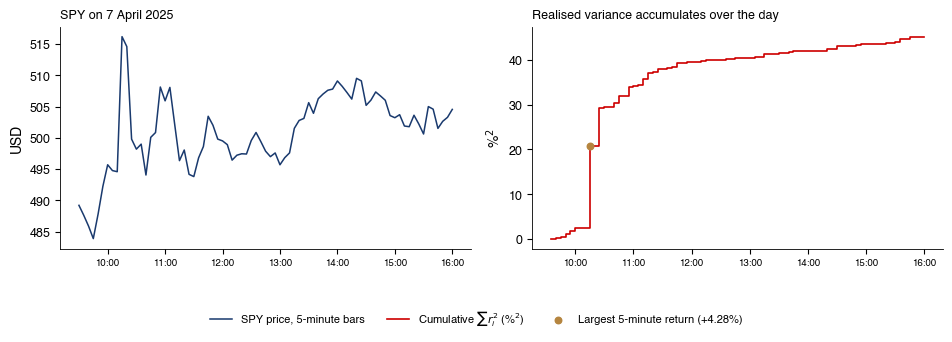

{'day': '2025-04-07',
 'rv': 45.14579516498878,
 'vol': 106.66180376112703,
 'n': 78,
 'max_ret': 4.276681403621829,
 'max_time': '10:15',
 'max_share': 0.4051319455387274,
 'oc': 3.0896172773615156,
 'on': -3.267894978785783}

In [5]:
def fig_intraday_day(day='2025-04-07'):
    """Pretul SPY pe bare de 5 minute intr-o zi agitata si suma cumulata a patratelor randamentelor."""
    d = pd.Timestamp(day)
    p = P_SPY.loc[d].dropna()
    r = R_SPY.loc[d].dropna()
    times = pd.date_range(d + pd.Timedelta('09:30:00'), periods=len(p), freq='5min')
    fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.1))
    axes[0].plot(times, p.values, color=MainBlue, lw=1.1, label='SPY price, 5-minute bars')
    axes[0].set_ylabel('USD')
    axes[0].set_title('SPY on 7 April 2025', fontsize=9, loc='left')
    cum = (r ** 2).cumsum()
    axes[1].step(times[1:], cum.values, where='post', color=IDAred, lw=1.2, label=r'Cumulative $\sum r_i^2$ (%$^2$)')
    big = int(np.argmax(np.abs(r.values)))
    axes[1].scatter(times[1 + big], cum.values[big], color=Amber, zorder=3, s=22,
                    label=f'Largest 5-minute return ({r.values[big]:+.2f}%)')
    axes[1].set_ylabel('%$^2$')
    axes[1].set_title('Realised variance accumulates over the day', fontsize=9, loc='left')
    for ax in axes:
        ax.tick_params(axis='x', labelsize=7)
        ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M'))
    fig_legend_bottom(fig, ncol=3, y=0.02)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save_fig('ch9_intraday_day')
    return {'day': day, 'rv': float(r.pow(2).sum()), 'vol': float(ann(r.pow(2).sum(), 252)), 'n': int(len(r)),
            'max_ret': float(r.values[big]), 'max_time': str(times[1 + big].time())[:5],
            'max_share': float(r.values[big] ** 2 / r.pow(2).sum()), 'oc': float(OC[d]), 'on': float(ON[d])}


fig_intraday_day()

## 2. Volatilitatea realizată zilnică și randamentul peste noapte

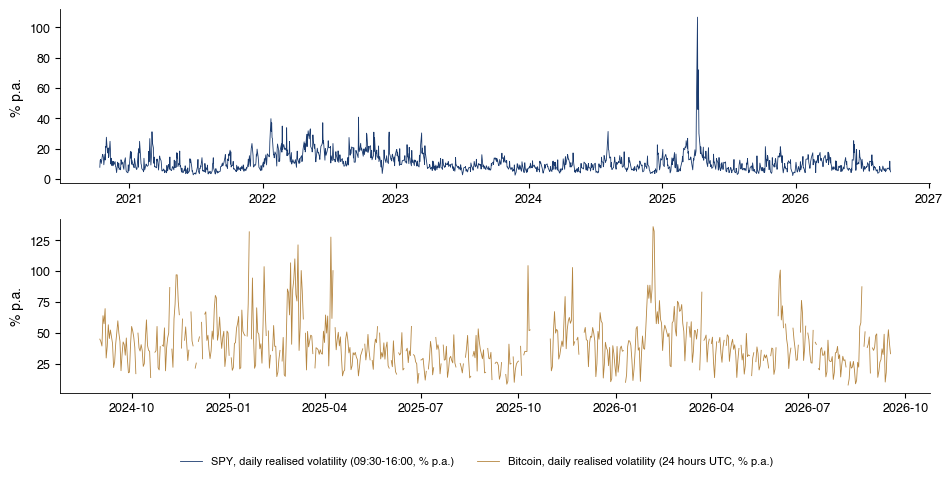

{'spy_mean': 12.928990072875376,
 'spy_med': 9.669369261160707,
 'spy_max': 106.66180376112703,
 'spy_maxdate': '2025-04-07',
 'spy_min': 2.3811511201695823,
 'spy_n': 1489,
 'btc_mean': 45.08053309755468,
 'btc_med': 37.752704185505166,
 'btc_max': 136.1192668412982,
 'btc_maxdate': '2026-02-05',
 'btc_n': 659,
 'spy_start': '2020-10-12',
 'btc_start': '2024-09-01',
 'btc_calendar': 747}

In [6]:
def fig_rv_series():
    """Volatilitatea realizata zilnica anualizata: SPY (intraday) si Bitcoin (24 de ore)."""
    fig, axes = plt.subplots(2, 1, figsize=(9.6, 4.6), sharex=False)
    axes[0].plot(RV_SPY.index, ann(RV_SPY, 252), color=MainBlue, lw=0.6, label='SPY, daily realised volatility (09:30-16:00, % p.a.)')
    axes[1].plot(RV_BTC.asfreq('D').index, ann(RV_BTC.asfreq('D'), 365), color=Amber, lw=0.6, label='Bitcoin, daily realised volatility (24 hours UTC, % p.a.)')
    for ax in axes:
        ax.set_ylabel('% p.a.')
    fig_legend_bottom(fig, ncol=2, y=0.02)
    plt.tight_layout(rect=(0, 0.06, 1, 1))
    save_fig('ch9_rv_series')
    vs, vb = ann(RV_SPY, 252), ann(RV_BTC, 365)
    return {'spy_mean': float(ann(RV_SPY.mean(), 252)), 'spy_med': float(vs.median()), 'spy_max': float(vs.max()),
            'spy_maxdate': str(vs.idxmax().date()), 'spy_min': float(vs.min()), 'spy_n': int(len(vs)),
            'btc_mean': float(ann(RV_BTC.mean(), 365)), 'btc_med': float(vb.median()), 'btc_max': float(vb.max()),
            'btc_maxdate': str(vb.idxmax().date()), 'btc_n': int(len(vb)),
            'spy_start': str(RV_SPY.index[0].date()), 'btc_start': str(RV_BTC.index[0].date()),
            'btc_calendar': int((RV_BTC.index[-1] - RV_BTC.index[0]).days + 1)}


fig_rv_series()

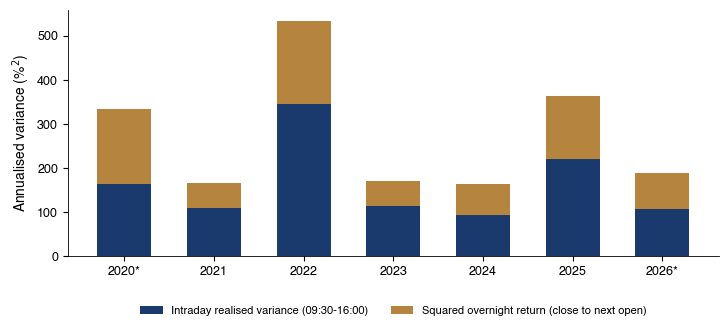

{'share': 0.38105238590429363,
 'share_by_year': {2020: 0.5094656135647019,
  2021: 0.3460299798134865,
  2022: 0.35306514624683016,
  2023: 0.33310007864584895,
  2024: 0.43395118790716974,
  2025: 0.3889656424843862,
  2026: 0.43698792431800276},
 'cc_vol': 16.625991347313107,
 'rvt_vol': 16.433787063264777,
 'oc_vol': 13.556608849823226,
 'on_vol': 10.12511050975266,
 'max_on': 4.077040940993554,
 'max_on_date': '2024-08-05',
 'max_on_val': -4.077040940993554}

In [7]:
def fig_overnight():
    """Descompunerea variantei zilnice SPY pe ani: partea intraday si randamentul peste noapte."""
    df = pd.DataFrame({'intraday': RV_SPY, 'overnight': ON ** 2})
    y = df.groupby(df.index.year).mean()
    fig, ax = plt.subplots(figsize=(8.4, 3.2))
    ax.bar(y.index, 252 * y['intraday'], color=MainBlue, width=0.6, label='Intraday realised variance (09:30-16:00)')
    ax.bar(y.index, 252 * y['overnight'], bottom=252 * y['intraday'], color=Amber, width=0.6,
           label='Squared overnight return (close to next open)')
    ax.set_ylabel('Annualised variance (%$^2$)')
    ax.set_xticks(y.index)
    ax.set_xticklabels([f'{k}*' if k in (2020, 2026) else str(k) for k in y.index])
    legend_outside_bottom(ax, ncol=2, y=-0.16)
    save_fig('ch9_overnight')
    share = (ON ** 2).sum() / (RV_SPY.sum() + (ON ** 2).sum())
    sh_y = (y['overnight'] / (y['intraday'] + y['overnight']))
    return {'share': float(share), 'share_by_year': {int(k): float(v) for k, v in sh_y.items()},
            'cc_vol': float(CC.std() * np.sqrt(252)), 'rvt_vol': float(ann(RVT_SPY.mean(), 252)),
            'oc_vol': float(OC.std() * np.sqrt(252)), 'on_vol': float(ON.std() * np.sqrt(252)),
            'max_on': float(ON.abs().max()), 'max_on_date': str(ON.abs().idxmax().date()), 'max_on_val': float(ON[ON.abs().idxmax()])}


fig_overnight()

## 3. Intervale de încredere pentru volatilitatea integrată

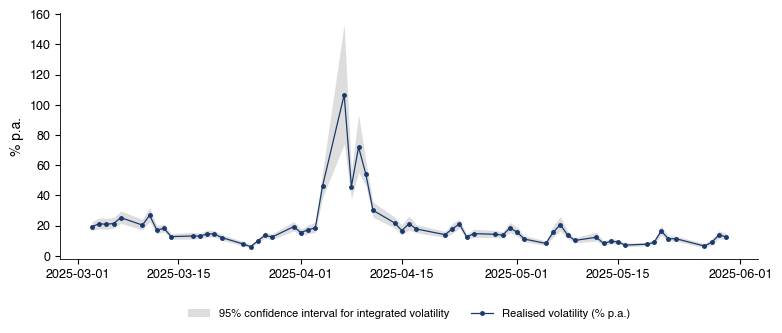

{'rel_width_med': 0.3650089387934251,
 'd': '2025-04-09',
 'd_vol': 72.00154637684531,
 'd_lo': 55.46786669712577,
 'd_hi': 93.46353103797378,
 'q_med': 0.1852138328808514}

In [8]:
def fig_rv_ci(a='2025-03-01', b='2025-05-30'):
    """RV zilnica SPY cu intervalul de incredere de 95% (Barndorff-Nielsen si Shephard), martie-mai 2025."""
    lo, hi = rv_ci(R_SPY)
    s = slice(a, b)
    fig, ax = plt.subplots(figsize=(9.0, 3.2))
    ax.fill_between(RV_SPY.loc[s].index, ann(lo.loc[s], 252), ann(hi.loc[s], 252), color=LightGray, alpha=0.9, lw=0,
                    label='95% confidence interval for integrated volatility')
    ax.plot(RV_SPY.loc[s].index, ann(RV_SPY.loc[s], 252), 'o-', color=MainBlue, ms=2.5, lw=0.9,
            label='Realised volatility (% p.a.)')
    ax.set_ylabel('% p.a.')
    legend_outside_bottom(ax, ncol=2, y=-0.16)
    save_fig('ch9_rv_ci')
    width = (ann(hi, 252) - ann(lo, 252)) / ann(RV_SPY, 252)
    d = pd.Timestamp('2025-04-09')
    return {'rel_width_med': float(width.median()), 'd': str(d.date()), 'd_vol': float(ann(RV_SPY[d], 252)),
            'd_lo': float(ann(lo[d], 252)), 'd_hi': float(ann(hi[d], 252)),
            'q_med': float(np.sqrt(2 / 3 * (R_SPY ** 4).sum(axis=1) / RV_SPY ** 2).median())}


fig_rv_ci()

## 4. Sezonalitatea intraday

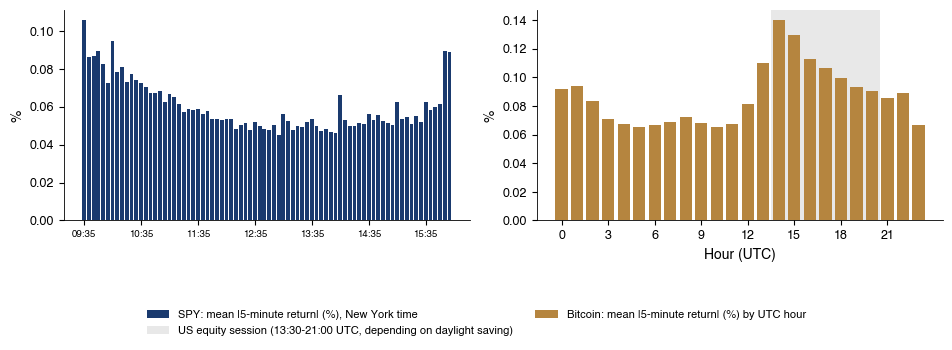

{'spy_first': 0.1058744533013933,
 'spy_mid': 0.05043530074747891,
 'spy_last': 0.08878127892819321,
 'spy_ratio': 2.0992132837967783,
 'btc_max_hour': 14,
 'btc_min_hour': 10,
 'btc_ratio': 2.15286254229018}

In [9]:
def fig_seasonality():
    """Media |r| pe intervale de 5 minute: SPY (forma de U) si Bitcoin pe ore UTC."""
    full = R_SPY[R_SPY.notna().sum(axis=1) == 78]
    s = full.abs().mean()
    tb = R_BTC.abs().mean().values.reshape(24, 12).mean(axis=1)
    fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.1))
    lab = pd.date_range('2000-01-01 09:35', periods=78, freq='5min')
    axes[0].bar(np.arange(78), s.values, color=MainBlue, width=0.8, label='SPY: mean |5-minute return| (%), New York time')
    ticks = [0, 12, 24, 36, 48, 60, 72]
    axes[0].set_xticks(ticks)
    axes[0].set_xticklabels([lab[i].strftime('%H:%M') for i in ticks], fontsize=7)
    axes[1].bar(np.arange(24), tb, color=Amber, width=0.8, label='Bitcoin: mean |5-minute return| (%) by UTC hour')
    axes[1].axvspan(13.5, 20.5, color=LightGray, alpha=0.6, lw=0, zorder=0, label='US equity session (13:30-21:00 UTC, depending on daylight saving)')
    axes[1].set_xticks(range(0, 24, 3))
    axes[1].set_xlabel('Hour (UTC)')
    for ax in axes:
        ax.set_ylabel('%')
    fig_legend_bottom(fig, ncol=2, y=0.02)
    plt.tight_layout(rect=(0, 0.1, 1, 1))
    save_fig('ch9_seasonality')
    return {'spy_first': float(s.iloc[0]), 'spy_mid': float(s.iloc[30:50].mean()), 'spy_last': float(s.iloc[-1]),
            'spy_ratio': float(s.iloc[0] / s.iloc[30:50].mean()), 'btc_max_hour': int(np.argmax(tb)),
            'btc_min_hour': int(np.argmin(tb)), 'btc_ratio': float(tb.max() / tb.min())}


fig_seasonality()

## 5. Zgomotul de microstructură: simulare și grafice de semnătură

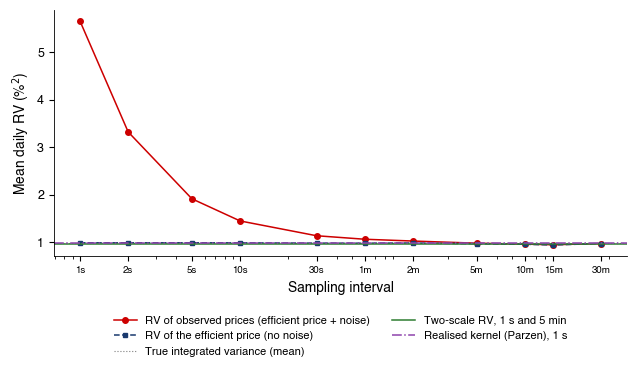

{'iv': 0.9848952976266009,
 'rv1s': 5.6577802032886835,
 'rv1m': 1.0595096436531743,
 'rv5m': 0.9763257544921727,
 'rv30m': 0.9693509102011276,
 'bias1s': 4.680000000000001,
 'bias1m': 0.078,
 'bias5m': 0.015600000000000001,
 'tsrv': 0.9519810674356503,
 'rk': 0.9899433187057249,
 'omega': 0.01,
 'n': 23400,
 'sd_rv5m': 0.18738229875248236,
 'sd_tsrv': 0.14984551487942568,
 'sd_rk': 0.04477845151475952}

In [10]:
def simulate_noise(days=100, n=23400, sigma=1.0, omega=0.01, seed=SEED):
    """Pret eficient (miscare browniana, volatilitate zilnica variabila) + zgomot i.i.d. N(0, omega^2), 1 secunda."""
    rng = np.random.default_rng(seed)
    sig_d = sigma * np.exp(0.3 * rng.standard_normal(days) - 0.045)
    X = np.cumsum(rng.standard_normal((days, n)) * (sig_d[:, None] / np.sqrt(n)), axis=1)
    X = np.c_[np.zeros(days), X]
    Y = X + omega * rng.standard_normal(X.shape)        # pretul observat (log x 100)
    return X, Y, sig_d ** 2


def fig_noise_simulation():
    """Graficul semnaturii pentru date simulate: RV explodeaza la frecvente mari; TSRV si nucleul realizat corecteaza."""
    X, Y, iv = simulate_noise()
    secs = [1, 2, 5, 10, 30, 60, 120, 300, 600, 900, 1800]
    sig = [np.mean(np.sum(np.diff(Y[:, ::k], axis=1) ** 2, axis=1)) for k in secs]
    sig_eff = [np.mean(np.sum(np.diff(X[:, ::k], axis=1) ** 2, axis=1)) for k in secs]
    n = Y.shape[1] - 1
    # TSRV: scara rapida 1 secunda, scara lenta 300 de secunde (K = 300)
    K = 300
    rv_all = np.sum(np.diff(Y, axis=1) ** 2, axis=1)
    rv_avg = np.mean([np.sum(np.diff(Y[:, o::K], axis=1) ** 2, axis=1) for o in range(K)], axis=0)
    nbar = (n - K + 1) / K
    tsrv = (rv_avg - nbar / n * rv_all) / (1 - nbar / n)
    # nucleu realizat Parzen pe randamente de 1 secunda
    rk = []
    for i in range(Y.shape[0]):
        r = np.diff(Y[i])
        om2 = np.sum(r ** 2) / (2 * n)
        iv20 = np.sum(np.diff(Y[i, ::1200]) ** 2)
        H = int(np.ceil(3.5134 * (om2 / iv20) ** 0.4 * n ** 0.6))
        g = [np.sum(r[h:] * r[:n - h]) for h in range(H + 1)]
        rk.append(g[0] + 2 * sum(parzen(h / (H + 1)) * g[h] for h in range(1, H + 1)))
    rk = np.array(rk)
    fig, ax = plt.subplots(figsize=(7.4, 3.2))
    ax.plot(secs, sig, 'o-', color=IDAred, ms=4, label='RV of observed prices (efficient price + noise)')
    ax.plot(secs, sig_eff, 's--', color=MainBlue, ms=3.5, label='RV of the efficient price (no noise)')
    ax.axhline(iv.mean(), color=Gray, lw=0.8, ls=':', label='True integrated variance (mean)')
    ax.axhline(tsrv.mean(), color=Forest, lw=1.1, label='Two-scale RV, 1 s and 5 min')
    ax.axhline(np.mean(rk), color=Purple, lw=1.1, ls='-.', label='Realised kernel (Parzen), 1 s')
    ax.set_xscale('log')
    ax.set_xticks(secs)
    ax.set_xticklabels(['1s', '2s', '5s', '10s', '30s', '1m', '2m', '5m', '10m', '15m', '30m'], fontsize=7)
    ax.set_xlabel('Sampling interval')
    ax.set_ylabel('Mean daily RV (%$^2$)')
    legend_outside_bottom(ax, ncol=2, y=-0.2)
    save_fig('ch9_noise_simulation')
    return {'iv': float(iv.mean()), 'rv1s': float(sig[0]), 'rv1m': float(sig[5]), 'rv5m': float(sig[7]), 'rv30m': float(sig[-1]),
            'bias1s': float(2 * n * 0.01 ** 2), 'bias1m': float(2 * 390 * 0.01 ** 2), 'bias5m': float(2 * 78 * 0.01 ** 2),
            'tsrv': float(tsrv.mean()), 'rk': float(rk.mean()), 'omega': 0.01, 'n': n,
            'sd_rv5m': float(np.std(np.sum(np.diff(Y[:, ::300], axis=1) ** 2, axis=1) - iv)),
            'sd_tsrv': float(np.std(tsrv - iv)), 'sd_rk': float(np.std(rk - iv))}


fig_noise_simulation()

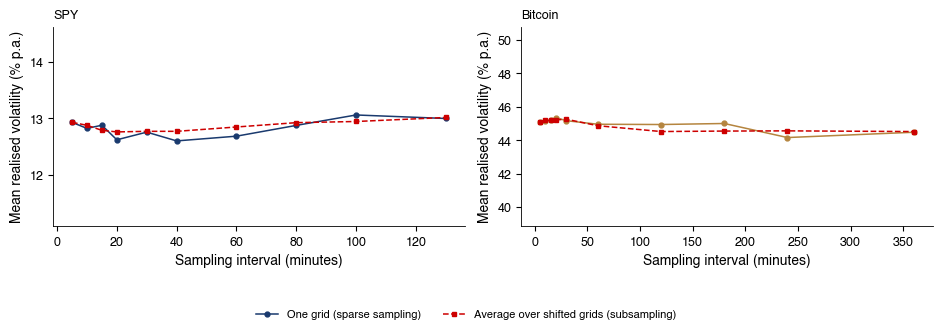

{'spy5': 12.928990072875376,
 'spy30': 12.769192237004653,
 'spy130': 13.014521133365532,
 'spy_range': 0.4599332806011951,
 'btc5': 45.08053309755468,
 'btc60': 44.873767200600945,
 'btc360': 44.525589051767845,
 'spy_rho1': -0.008428916144238102,
 'btc_rho1': 0.0051971833404140045,
 'spy_om2rv': 0.004257999798765012,
 'tsrv_ratio': 0.9708965831452396,
 'rk_ratio': 0.9518485395708459,
 'rk_H_med': 7.0,
 'corr_rk_rv': 0.8452249403602468,
 'corr_ts_rv': 0.8924165150735445}

In [11]:
KS_SPY = [1, 2, 3, 4, 6, 8, 12, 16, 20, 26]
KS_BTC = [1, 2, 3, 4, 6, 12, 24, 36, 48, 72]


def fig_signature():
    """Graficul semnaturii empiric: SPY (5-130 de minute) si Bitcoin (5-360 de minute)."""
    ss = signature(P_SPY, KS_SPY, 252)
    sb = signature(P_BTC, KS_BTC, 365)
    fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.1))
    for ax, s, ks, col, name in [(axes[0], ss, KS_SPY, MainBlue, 'SPY'), (axes[1], sb, KS_BTC, Amber, 'Bitcoin')]:
        m = [5 * k for k in ks]
        ax.plot(m, s['sparse'], 'o-', color=col, ms=3.5, label='One grid (sparse sampling)')
        ax.plot(m, s['subsampled'], 's--', color=IDAred, ms=3, label='Average over shifted grids (subsampling)')
        ax.set_xlabel('Sampling interval (minutes)')
        ax.set_ylabel('Mean realised volatility (% p.a.)')
        ax.set_title(name, fontsize=9, loc='left')
        lo, hi = s.values.min(), s.values.max()
        ax.set_ylim(lo - 0.12 * lo, hi + 0.12 * hi)
    fig_legend_bottom(fig, ncol=2, y=0.02)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save_fig('ch9_signature')
    nz_s, nz_b = noise_var(R_SPY), noise_var(R_BTC)
    ts = tsrv(P_SPY, 6)
    nbar = (nret(R_SPY) - 5) / 6
    ts_adj = ts / (1 - nbar / nret(R_SPY))
    rk, H = realized_kernel(R_SPY, P_SPY)
    return {'spy5': float(ss['sparse'].iloc[0]), 'spy30': float(ss['subsampled'].loc[6]), 'spy130': float(ss['subsampled'].iloc[-1]),
            'spy_range': float(ss.values.max() - ss.values.min()),
            'btc5': float(sb['sparse'].iloc[0]), 'btc60': float(sb['subsampled'].loc[12]), 'btc360': float(sb['subsampled'].iloc[-1]),
            'spy_rho1': nz_s['rho1'], 'btc_rho1': nz_b['rho1'], 'spy_om2rv': nz_s['omega2_rv'],
            'tsrv_ratio': float(ts_adj.mean() / RV_SPY.mean()), 'rk_ratio': float(rk.mean() / RV_SPY.mean()),
            'rk_H_med': float(H.median()), 'corr_rk_rv': float(np.corrcoef(rk, RV_SPY)[0, 1]),
            'corr_ts_rv': float(np.corrcoef(ts_adj, RV_SPY)[0, 1])}


fig_signature()

## 6. Salturi: variația bipower și testul raportului

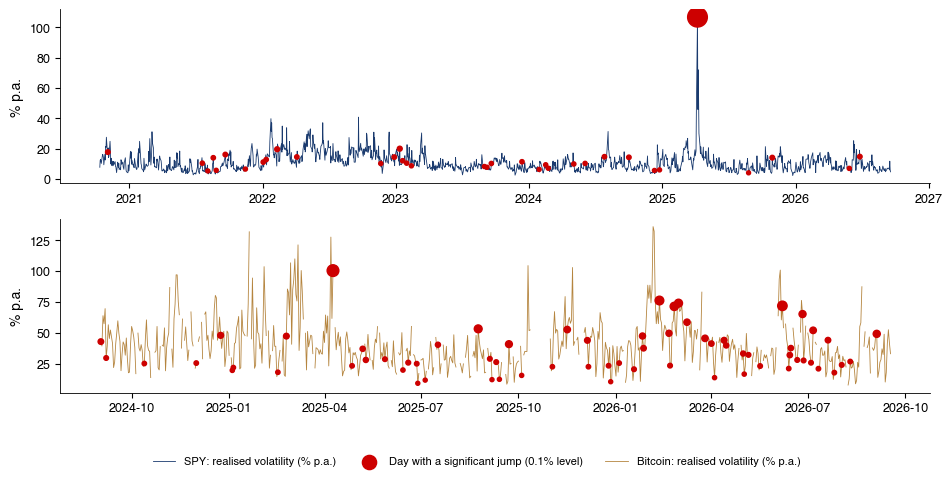

{'spy': {'share': 0.02350570852921424,
  'n_jump': 35,
  'N': 1489,
  'jshare': 0.028357370498370525,
  'bv_rv': 0.9530727107555614,
  'top_date': '2021-08-27',
  'top_z': 5.218990969338793,
  'top_jshare': 0.49309151100370663,
  'top_rv_vol': 5.842055243469691,
  'mean_jshare_on_jump': 0.35291851475100655},
 'btc': {'share': 0.10166919575113809,
  'n_jump': 67,
  'N': 659,
  'jshare': 0.018446058414483185,
  'bv_rv': 0.9271958728298676,
  'top_date': '2026-07-26',
  'top_z': 6.661244348247837,
  'top_jshare': 0.37300626742631565,
  'top_rv_vol': 17.892534470420117,
  'mean_jshare_on_jump': 0.2303616779255817}}

In [12]:
def fig_jumps():
    """Zilele cu salt semnificativ (nivel 0,1%): SPY si Bitcoin; marimea punctului = componenta de salt."""
    js, jb = jump_test(R_SPY), jump_test(R_BTC)
    fig, axes = plt.subplots(2, 1, figsize=(9.6, 4.6))
    for ax, j, col, ppy, name in [(axes[0], js, MainBlue, 252, 'SPY'), (axes[1], jb, Amber, 365, 'Bitcoin')]:
        jv = j['rv'].asfreq('D') if name == 'Bitcoin' else j['rv']
        ax.plot(jv.index, ann(jv, ppy), color=col, lw=0.6, label=f'{name}: realised volatility (% p.a.)')
        jj = j[j['jump']]
        ax.scatter(jj.index, ann(jj['rv'], ppy), s=8 + 400 * jj['J'] / j['rv'].max(), color=IDAred, zorder=3,
                   label='Day with a significant jump (0.1% level)')
        ax.set_ylabel('% p.a.')
    fig_legend_bottom(fig, ncol=3, y=0.02)
    plt.tight_layout(rect=(0, 0.06, 1, 1))
    save_fig('ch9_jumps')
    out = {}
    for k, j, R in [('spy', js, R_SPY), ('btc', jb, R_BTC)]:
        top = j.loc[j['z'].idxmax()]
        out[k] = {'share': float(j['jump'].mean()), 'n_jump': int(j['jump'].sum()), 'N': int(len(j)),
                  'jshare': float(j['J'].sum() / j['rv'].sum()), 'bv_rv': float((j['bv'] / j['rv']).mean()),
                  'top_date': str(j['z'].idxmax().date()), 'top_z': float(top['z']),
                  'top_jshare': float(top['J'] / top['rv']), 'top_rv_vol': float(ann(top['rv'], 252 if k == 'spy' else 365)),
                  'mean_jshare_on_jump': float((j.loc[j['jump'], 'J'] / j.loc[j['jump'], 'rv']).mean())}
    return out


fig_jumps()

## 7. Fapte stilizate: distribuții, memorie lungă, VIX

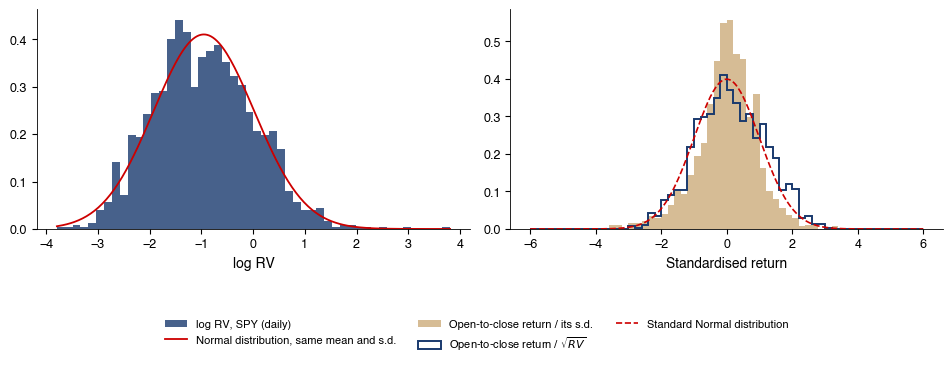

{'lv_skew': 0.2924729562895697,
 'lv_kurt': 3.2026097635519704,
 'v_skew': 19.989419884616293,
 'v_kurt': 549.7625875392608,
 'lvb_skew': -0.2707088343711959,
 'lvb_kurt': 3.33029077801773,
 'u_kurt': 15.732926393989384,
 'z_kurt': 2.6541534328371674,
 'z_sd': 1.0537954738243898,
 'jb_u': 10143.198168992685,
 'jb_z': 7.607467835613392,
 'jb_z_p': 0.022287396987105104,
 'ub_kurt': 7.566126114846244,
 'zb_kurt': 2.7693713230360335}

In [13]:
def CC_BTC_UTC():
    """Randamentul zilnic Bitcoin (UTC) din barele de 5 minute: deschiderea de 00:00 -> ultima inchidere."""
    return 100 * np.log(P_BTC.iloc[:, -1] / P_BTC[0])


def fig_distributions():
    """Stanga: log RV (SPY) si distributia Normala; dreapta: r/sd(r) vs r/sqrt(RV) (Andersen et al.)."""
    lv = np.log(RV_SPY)
    z = OC / np.sqrt(RV_SPY)
    u = OC / OC.std()
    fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.2))
    axes[0].hist(lv, bins=50, density=True, color=MainBlue, alpha=0.8, label='log RV, SPY (daily)')
    x = np.linspace(lv.min(), lv.max(), 200)
    axes[0].plot(x, stats.norm.pdf(x, lv.mean(), lv.std()), color=IDAred, lw=1.3, label='Normal distribution, same mean and s.d.')
    axes[0].set_xlabel('log RV')
    bins = np.linspace(-6, 6, 61)
    axes[1].hist(u.clip(-6, 6), bins=bins, density=True, color=Amber, alpha=0.55, label=r'Open-to-close return / its s.d.')
    axes[1].hist(z.clip(-6, 6), bins=bins, density=True, histtype='step', color=MainBlue, lw=1.4, label=r'Open-to-close return / $\sqrt{RV}$')
    xx = np.linspace(-6, 6, 300)
    axes[1].plot(xx, stats.norm.pdf(xx), color=IDAred, lw=1.2, ls='--', label='Standard Normal distribution')
    axes[1].set_xlabel('Standardised return')
    fig_legend_bottom(fig, ncol=3, y=0.02)
    plt.tight_layout(rect=(0, 0.1, 1, 1))
    save_fig('ch9_distributions')
    lvb = np.log(RV_BTC)
    zb = CC_BTC_UTC() / np.sqrt(RV_BTC)
    return {'lv_skew': float(stats.skew(lv)), 'lv_kurt': float(stats.kurtosis(lv) + 3),
            'v_skew': float(stats.skew(RV_SPY)), 'v_kurt': float(stats.kurtosis(RV_SPY) + 3),
            'lvb_skew': float(stats.skew(lvb)), 'lvb_kurt': float(stats.kurtosis(lvb) + 3),
            'u_kurt': float(stats.kurtosis(u) + 3), 'z_kurt': float(stats.kurtosis(z) + 3), 'z_sd': float(z.std()),
            'jb_u': float(stats.jarque_bera(u).statistic), 'jb_z': float(stats.jarque_bera(z).statistic),
            'jb_z_p': float(stats.jarque_bera(z).pvalue),
            'ub_kurt': float(stats.kurtosis(CC_BTC_UTC() / CC_BTC_UTC().std()) + 3), 'zb_kurt': float(stats.kurtosis(zb) + 3)}


fig_distributions()

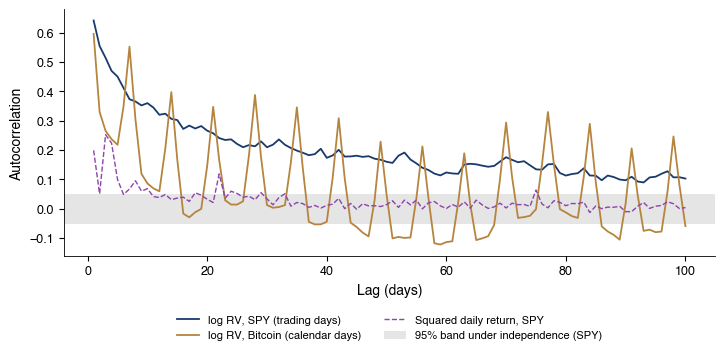

{'btc_weekend_ratio': 0.4137191150481175,
 'btc_sat': 27.339455741935858,
 'btc_wed': 48.004584861379314,
 'btc7': 0.5522917843102126,
 'btc3': 0.2653353002503572,
 'spy1': 0.6413512379219026,
 'spy22': 0.24089218714508417,
 'spy100': 0.10291654030322757,
 'btc1': 0.5957804740153603,
 'btc30': 0.012780056850089127,
 'btc100': -0.05879493511817613,
 'sq1': 0.19900823097048698,
 'sq22': 0.1187560155032992,
 'band': 0.050793568177147724}

In [14]:
def acf(x, lags):
    x = np.asarray(x) - np.mean(x)
    return np.array([np.sum(x[l:] * x[:-l]) / np.sum(x * x) for l in range(1, lags + 1)])


def fig_acf():
    """Autocorelatiile log RV (SPY, Bitcoin) si ale randamentelor zilnice la patrat (SPY): memorie lunga."""
    L = 100
    a1 = acf(np.log(RVT_SPY), L)
    b = np.log(RV_BTC.asfreq('D')).interpolate()
    a2 = acf(b.values, L)
    a3 = acf((CC ** 2).values, L)
    fig, ax = plt.subplots(figsize=(8.4, 3.2))
    lg = np.arange(1, L + 1)
    ax.plot(lg, a1, color=MainBlue, lw=1.3, label='log RV, SPY (trading days)')
    ax.plot(lg, a2, color=Amber, lw=1.3, label='log RV, Bitcoin (calendar days)')
    ax.plot(lg, a3, color=Purple, lw=1.0, ls='--', label='Squared daily return, SPY')
    band = 1.96 / np.sqrt(len(RVT_SPY))
    ax.axhspan(-band, band, color=LightGray, alpha=0.7, lw=0, label='95% band under independence (SPY)')
    ax.set_xlabel('Lag (days)')
    ax.set_ylabel('Autocorrelation')
    legend_outside_bottom(ax, ncol=2, y=-0.2)
    save_fig('ch9_acf')
    dow = RV_BTC.groupby(RV_BTC.index.dayofweek).mean()
    return {'btc_weekend_ratio': float(dow[[5, 6]].mean() / dow[[0, 1, 2, 3, 4]].mean()),
            'btc_sat': float(ann(dow[5], 365)), 'btc_wed': float(ann(dow[2], 365)), 'btc7': float(a2[6]), 'btc3': float(a2[2]),
            'spy1': float(a1[0]), 'spy22': float(a1[21]), 'spy100': float(a1[99]), 'btc1': float(a2[0]),
            'btc30': float(a2[29]), 'btc100': float(a2[99]), 'sq1': float(a3[0]), 'sq22': float(a3[21]),
            'band': float(band)}


fig_acf()

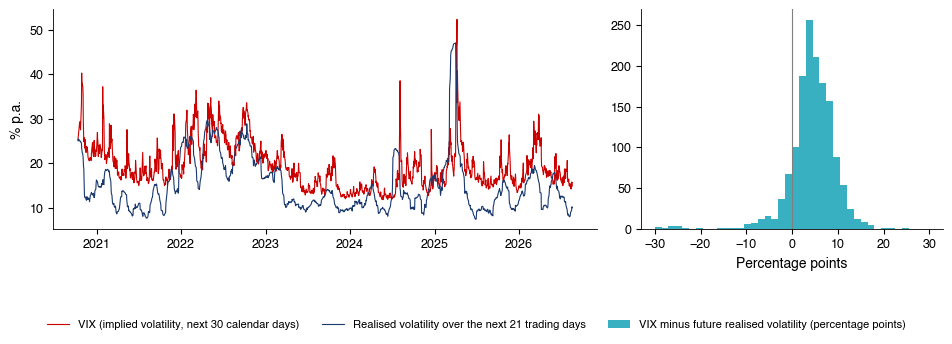

{'vix_mean': 19.518623978201635,
 'fvol_mean': 15.152595862975067,
 'vrp_mean': 138.2542621372983,
 'vrp_pos': 0.8773841961852861,
 'corr': 0.5928431113270157,
 'mz_b': np.float64(0.5574691605945066),
 'mz_se_b': np.float64(0.0512433161113418),
 'mz_r2': np.float64(0.23166329091739468),
 'N': 1468,
 'vrp_min_date': '2025-03-25',
 'vrp_min': -1898.7247181014136,
 'gap_mean': 4.366028115226567,
 'gap_med': 4.586048864333174,
 'gap_out': 0}

In [15]:
def fig_vix():
    """VIX (volatilitatea implicita pe 30 de zile) vs volatilitatea realizata in urmatoarele 21 de zile (SPY, cu noaptea)."""
    vix = daily_close('vix').reindex(RVT_SPY.index).ffill()
    fut = RVT_SPY[::-1].rolling(21).sum()[::-1].shift(-1)          # suma RV pe zilele t+1..t+21
    fvol = np.sqrt(252 / 21 * fut)
    df = pd.DataFrame({'vix': vix, 'fvol': fvol}).dropna()
    fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.2), gridspec_kw={'width_ratios': [1.8, 1]})
    axes[0].plot(df.index, df['vix'], color=IDAred, lw=0.8, label='VIX (implied volatility, next 30 calendar days)')
    axes[0].plot(df.index, df['fvol'], color=MainBlue, lw=0.8, label='Realised volatility over the next 21 trading days')
    axes[0].set_ylabel('% p.a.')
    vrp = df['vix'] ** 2 - df['fvol'] ** 2
    gap = df['vix'] - df['fvol']
    axes[1].hist(gap, bins=np.arange(-30, 31, 1.5), color=Teal, alpha=0.85,
                 label='VIX minus future realised volatility (percentage points)')
    axes[1].axvline(0, color=Gray, lw=0.8)
    axes[1].set_xlabel('Percentage points')
    fig_legend_bottom(fig, ncol=3, y=0.02)
    plt.tight_layout(rect=(0, 0.1, 1, 1))
    save_fig('ch9_vix')
    mz = mz_test(df['fvol'] ** 2, df['vix'] ** 2)
    return {'vix_mean': float(df['vix'].mean()), 'fvol_mean': float(df['fvol'].mean()),
            'vrp_mean': float(vrp.mean()), 'vrp_pos': float((vrp > 0).mean()), 'corr': float(df['vix'].corr(df['fvol'])),
            'mz_b': mz['b'], 'mz_se_b': mz['se_b'], 'mz_r2': mz['r2'], 'N': int(len(df)),
            'vrp_min_date': str(vrp.idxmin().date()), 'vrp_min': float(vrp.min()),
            'gap_mean': float(gap.mean()), 'gap_med': float(gap.median()), 'gap_out': int(((gap < -30) | (gap > 30)).sum())}


fig_vix()

## 8. Modelul HAR-RV

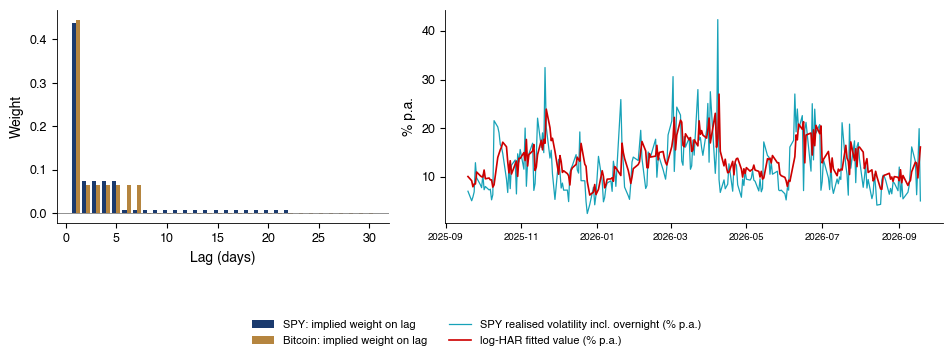

,spy_lev,spy_log,btc_lev,btc_log
const,0.273,-0.079,1.496,0.223
daily,0.399,0.362,0.412,0.380
weekly,0.222,0.337,0.409,0.465
monthly,0.114,0.167,-0.065,-0.022


In [16]:
def har_tables():
    """HAR si log-HAR pe esantionul complet: SPY (varianta totala) si Bitcoin (24 de ore)."""
    out = {}
    for k, v, cal in [('spy', RVT_SPY, False), ('btc', RV_BTC, True)]:
        for tag, log in [('lev', False), ('log', True)]:
            res, X, ok = har_fit(v, calendar=cal, log=log)
            out[f'{k}_{tag}'] = {'b': res['b'], 'se': res['se'], 'r2': res['r2'], 'T': res['T'], 'lags': res['lags'],
                                 'pers': float(sum(res['b'][1:]))}
    return out


def fig_har(tab):
    """Stanga: ponderile implicite ale log-HAR pe intarzieri (SPY, Bitcoin); dreapta: log-HAR SPY in esantion, ultimele 250 de zile."""
    ws = har_weights(tab['spy_log']['b'], 30)
    wb = har_weights(tab['btc_log']['b'], 30)
    # Bitcoin: saptamana = 7 zile, luna = 30 de zile calendaristice
    b = tab['btc_log']['b']
    wb = np.zeros(30)
    wb[0] += b[1]
    wb[:7] += b[2] / 7
    wb[:30] += b[3] / 30
    res, X, ok = har_fit(RVT_SPY, log=True)
    fit = pd.Series(np.column_stack([np.ones(ok.sum()), X[ok].values]) @ res['b'], index=X[ok].index)
    fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.2), gridspec_kw={'width_ratios': [1, 1.5]})
    lg = np.arange(1, 31)
    axes[0].bar(lg - 0.2, ws, 0.4, color=MainBlue, label='SPY: implied weight on lag')
    axes[0].bar(lg + 0.2, wb, 0.4, color=Amber, label='Bitcoin: implied weight on lag')
    axes[0].axhline(0, color=Gray, lw=0.6)
    axes[0].set_xlabel('Lag (days)')
    last = fit.index[-250:]
    axes[1].plot(last, ann(RVT_SPY.loc[last], 252), color=Teal, lw=0.9, label='SPY realised volatility incl. overnight (% p.a.)')
    axes[1].plot(last, ann(np.exp(fit.loc[last] + res['resid'].var() / 2), 252), color=IDAred, lw=1.2,
                 label='log-HAR fitted value (% p.a.)')
    axes[1].tick_params(axis='x', labelsize=7)
    axes[1].set_ylabel('% p.a.')
    axes[0].set_ylabel('Weight')
    fig_legend_bottom(fig, ncol=2, y=0.02)
    plt.tight_layout(rect=(0, 0.12, 1, 1))
    save_fig('ch9_har')
    return {'w1_spy': float(ws[0]), 'w5_spy': float(ws[4]), 'w6_spy': float(ws[5]), 'w22_spy': float(ws[21]), 'w23_spy': float(ws[22]),
            'w1_btc': float(wb[0]), 'w7_btc': float(wb[6]), 'w8_btc': float(wb[7])}


tab = har_tables()
fig_har(tab)
pd.DataFrame({k: v['b'] for k, v in tab.items()}, index=['const', 'daily', 'weekly', 'monthly']).round(3)

In [17]:
# Erori standard Newey-West și R^2
pd.DataFrame({k: list(v['se']) + [v['r2']] for k, v in tab.items()}, index=['const', 'daily', 'weekly', 'monthly', 'R2']).round(3)

,spy_lev,spy_log,btc_lev,btc_log
const,0.064,0.027,0.412,0.094
daily,0.089,0.037,0.089,0.041
weekly,0.096,0.048,0.122,0.080
monthly,0.053,0.044,0.097,0.098
R2,0.315,0.470,0.344,0.364


## 9. Prognoze în afara eșantionului: log-HAR, HAR, GARCH(1,1)-t, EWMA, RV de ieri

In [18]:
def oos_forecasts(v, r, start, calendar):
    """Prognoze pentru ziua urmatoare: HAR, log-HAR (fereastra extinsa), GARCH(1,1)-t si EWMA pe randamente zilnice, RV de ieri."""
    idx = v.loc[start:].index
    F = pd.DataFrame({
        'logHAR': har_expanding(v, start, calendar=calendar, log=True),
        'HAR': har_expanding(v, start, calendar=calendar),
        'GARCH-t': garch_forecasts(r, idx),
        'EWMA': ewma_forecasts(r).reindex(idx),
        'RW': (v.asfreq('D').shift(1).reindex(idx) if calendar else v.shift(1).reindex(idx))}).dropna()
    return F, v.reindex(F.index)


def evaluate(F, y):
    """Pierderi medii QLIKE si MSE, R^2 Mincer-Zarnowitz, teste DM fata de log-HAR."""
    out = {}
    for c in F:
        mz = mz_test(y, F[c])
        out[c] = {'qlike': float(qlike(y, F[c]).mean()), 'mse': float(mse(y, F[c]).mean()),
                  'mz_a': mz['a'], 'mz_b': mz['b'], 'mz_se_a': mz['se_a'], 'mz_se_b': mz['se_b'], 'mz_r2': mz['r2'],
                  'mz_p': mz['p']}
        if c != 'logHAR':
            dq = dm_test(qlike(y, F['logHAR']), qlike(y, F[c]))
            dm = dm_test(mse(y, F['logHAR']), mse(y, F[c]))
            out[c].update({'dm_q_t': dq['t'], 'dm_q_p': dq['p'], 'dm_m_t': dm['t'], 'dm_m_p': dm['p']})
    out['T'] = int(len(F))
    out['start'] = str(F.index[0].date())
    return out


F, y = oos_forecasts(RVT_SPY, D_SPY, OOS_SPY, False)
Fb, yb = oos_forecasts(RV_BTC, D_BTC, OOS_BTC, True)
pd.DataFrame({k: v for k, v in evaluate(F, y).items() if isinstance(v, dict)}).round(3)

,logHAR,HAR,GARCH-t,EWMA,RW
qlike,0.310,0.326,0.343,0.393,0.502
mse,4.148,4.477,4.873,5.137,5.410
mz_a,-0.107,0.293,0.242,0.260,0.532
mz_b,1.164,0.745,0.705,0.740,0.537
mz_se_a,0.204,0.085,0.231,0.194,0.069
mz_se_b,0.246,0.083,0.238,0.232,0.075
mz_r2,0.296,0.264,0.204,0.137,0.288
mz_p,0.554,0.002,0.355,0.345,0.000
dm_q_t,NaN,-1.945,-2.302,-4.019,-5.947
dm_q_p,NaN,0.052,0.021,0.000,0.000


In [19]:
pd.DataFrame({k: v for k, v in evaluate(Fb, yb).items() if isinstance(v, dict)}).round(3)

,logHAR,HAR,GARCH-t,EWMA,RW
qlike,0.282,0.409,0.360,0.346,0.466
mse,26.605,27.585,42.224,36.286,34.974
mz_a,0.464,0.231,1.220,1.685,2.235
mz_b,0.823,0.891,0.553,0.645,0.578
mz_se_a,0.459,0.548,0.774,0.560,0.437
mz_se_b,0.097,0.113,0.130,0.133,0.082
mz_r2,0.381,0.341,0.232,0.178,0.328
mz_p,0.087,0.380,0.000,0.010,0.000
dm_q_t,NaN,-1.218,-4.318,-2.959,-5.382
dm_q_p,NaN,0.223,0.000,0.003,0.000


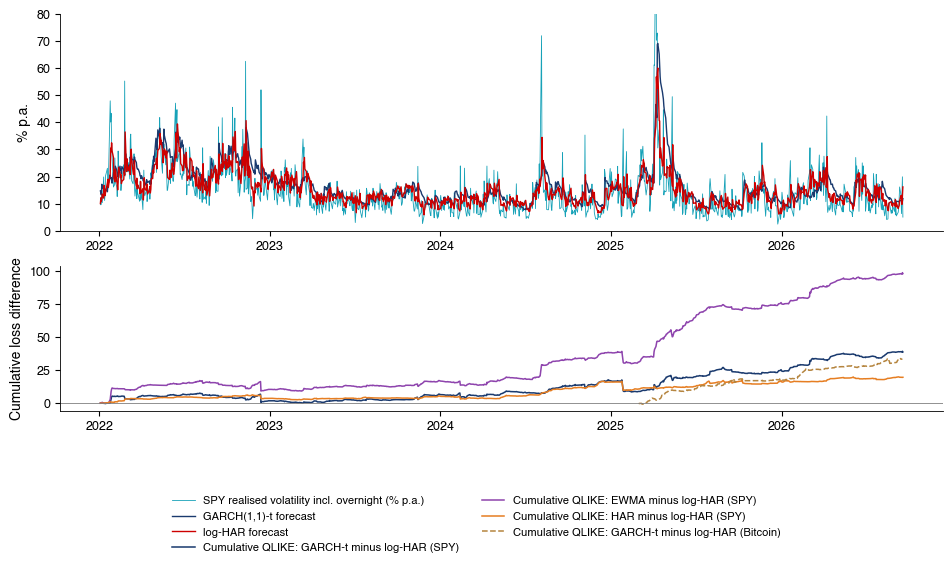

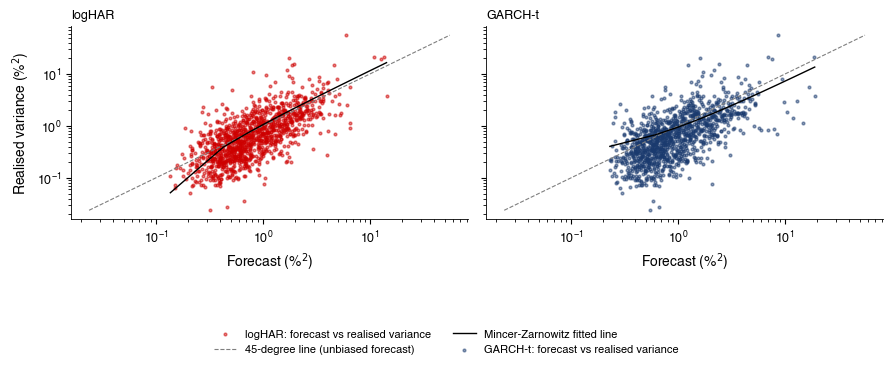

In [20]:
def fig_oos(F, y, Fb, yb):
    """SPY 2022-2026: volatilitatea realizata (inclusiv noaptea) si prognozele log-HAR si GARCH-t; pierderea QLIKE cumulata."""
    fig, axes = plt.subplots(2, 1, figsize=(9.6, 5.0), gridspec_kw={'height_ratios': [1.5, 1]})
    axes[0].plot(y.index, ann(y, 252), color=Teal, lw=0.6, label='SPY realised volatility incl. overnight (% p.a.)')
    axes[0].plot(F.index, ann(F['GARCH-t'], 252), color=MainBlue, lw=1.0, label='GARCH(1,1)-t forecast')
    axes[0].plot(F.index, ann(F['logHAR'], 252), color=IDAred, lw=1.0, label='log-HAR forecast')
    axes[0].set_ylabel('% p.a.')
    axes[0].set_ylim(0, 80)
    for c in ['GARCH-t', 'EWMA', 'HAR']:
        d = (qlike(y, F[c]) - qlike(y, F['logHAR'])).cumsum()
        axes[1].plot(d.index, d.values, color=MODEL_COL[c], lw=1.1, label=f'Cumulative QLIKE: {c} minus log-HAR (SPY)')
    for c in ['GARCH-t']:
        d = (qlike(yb, Fb[c]) - qlike(yb, Fb['logHAR'])).cumsum()
        axes[1].plot(d.index, d.values, color=Amber, lw=1.1, ls='--', label='Cumulative QLIKE: GARCH-t minus log-HAR (Bitcoin)')
    axes[1].axhline(0, color=Gray, lw=0.6)
    axes[1].set_ylabel('Cumulative loss difference')
    fig_legend_bottom(fig, ncol=2, y=0.02)
    plt.tight_layout(rect=(0, 0.1, 1, 1))
    save_fig('ch9_oos')


def fig_mz(F, y):
    """Regresiile Mincer-Zarnowitz pe scara log: log-HAR si GARCH-t (SPY, 2022-2026)."""
    fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.3), sharey=True)
    for ax, c in zip(axes, ['logHAR', 'GARCH-t']):
        ax.scatter(F[c], y, s=4, color=MODEL_COL[c], alpha=0.5, label=f'{c}: forecast vs realised variance')
        lim = [min(F[c].min(), y.min()), max(F[c].max(), y.max())]
        ax.plot(lim, lim, color=Gray, lw=0.8, ls='--', label='45-degree line (unbiased forecast)')
        mz = mz_test(y, F[c])
        xx = np.linspace(F[c].min(), F[c].max(), 50)
        ax.plot(xx, mz['a'] + mz['b'] * xx, color='black', lw=1.0, label='Mincer-Zarnowitz fitted line')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('Forecast (%$^2$)')
        ax.set_title(c, fontsize=9, loc='left')
    axes[0].set_ylabel('Realised variance (%$^2$)')
    fig_legend_bottom(fig, ncol=2, y=0.02)
    plt.tight_layout(rect=(0, 0.12, 1, 1))
    save_fig('ch9_mz')


fig_oos(F, y, Fb, yb)
fig_mz(F, y)

## 10. Volatilitatea aspră

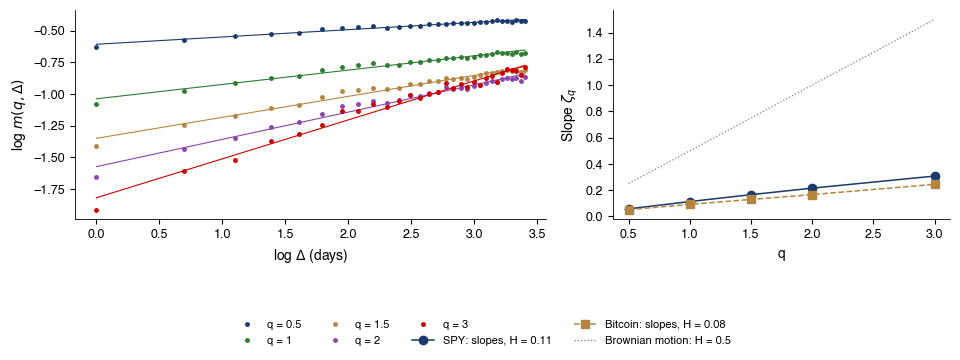

{'H_spy': 0.1057501363262207,
 'H_btc': 0.08353206006716946,
 'zeta2_spy': 0.21555183665551336,
 'zeta1_spy': 0.1133293691681224}

In [21]:
def rough_H(logsig, qs=(0.5, 1.0, 1.5, 2.0, 3.0), lags=range(1, 31)):
    """H = panta dreptei zeta_q = q H, prin origine."""
    ro = roughness(logsig, qs, lags)
    q = np.array(qs)
    z = np.array([ro['zeta'][x] for x in qs])
    ro['H'] = float(np.sum(q * z) / np.sum(q * q))
    return ro


def fig_rough():
    """log m(q, Delta) vs log Delta pentru log-volatilitatea SPY; pantele zeta_q = q H."""
    ro = rough_H(0.5 * np.log(RVT_SPY.values))
    rb = rough_H(0.5 * np.log(RV_BTC.asfreq('D').interpolate().values))
    fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.2), gridspec_kw={'width_ratios': [1.4, 1]})
    cols = [MainBlue, Forest, Amber, Purple, IDAred]
    for q, c in zip(ro['m'], cols):
        axes[0].plot(np.log(ro['lags']), np.log(ro['m'][q]), 'o', ms=2.5, color=c, label=f'q = {q:g}')
        fit = np.polyfit(np.log(ro['lags']), np.log(ro['m'][q]), 1)
        axes[0].plot(np.log(ro['lags']), np.polyval(fit, np.log(ro['lags'])), color=c, lw=0.8)
    axes[0].set_xlabel(r'log $\Delta$ (days)')
    axes[0].set_ylabel(r'log $m(q, \Delta)$')
    qs = np.array(list(ro['zeta']))
    axes[1].plot(qs, [ro['zeta'][q] for q in qs], 'o-', color=MainBlue, label=f'SPY: slopes, H = {ro["H"]:.2f}')
    axes[1].plot(qs, [rb['zeta'][q] for q in qs], 's--', color=Amber, label=f'Bitcoin: slopes, H = {rb["H"]:.2f}')
    axes[1].plot(qs, 0.5 * qs, color=Gray, ls=':', lw=0.9, label='Brownian motion: H = 0.5')
    axes[1].set_xlabel('q')
    axes[1].set_ylabel(r'Slope $\zeta_q$')
    fig_legend_bottom(fig, ncol=4, y=0.02)
    plt.tight_layout(rect=(0, 0.12, 1, 1))
    save_fig('ch9_rough')
    return {'H_spy': ro['H'], 'H_btc': rb['H'], 'zeta2_spy': float(ro['zeta'][2.0]), 'zeta1_spy': float(ro['zeta'][1.0])}


fig_rough()